In [28]:
(* ==================================================== *)
(* Задача о переправе через реку — референсное решение   *)
(* ==================================================== *)

(* --- 1. Параметры --- *)
kVal = 3/5;      (* k = v/u, отношение скоростей *)
x0 = 10;
y0 = 6;

In [35]:
(* --- 2. Задание ОДУ --- *)
ode = y'[x] == -y[x]/(kVal*Sqrt[x^2 + y[x]^2] - x);

In [37]:
(* --- 3. Проверка однородности f(λx,λy) = f(x,y) --- *)
f[x_, y_, k_] := -y/(k*Sqrt[x^2 + y^2] - x);
homogeneityCheck = Simplify[f[lam*x, lam*y, k] - f[x, y, k], lam > 0]
(* Ожидаемый результат: 0 *)

0

C[1]
                  1       -20 E     x
{{y[x] -> -Sqrt[-(-) Sqrt[----------- + 
                  2            3
 
                1/3      2 C[1]  2       C[1]  5
>           (4 2    (25 E       x  + 96 E     x )) / 
 
                          4 C[1]        3 C[1]  3          2 C[1]  6
>            (3 Power[27 E       - 160 E       x  + 20160 E       x  + 
 
                                    8 C[1]        7 C[1]  3           6 C[1]  6
>                3 Sqrt[3] Sqrt[27 E       - 320 E       x  - 106880 E       x  - 
 
                             5 C[1]  9            4 C[1]  12            3 C[1]  15
>                   1945600 E       x  + 8499200 E       x   - 8388608 E       x  ], 1/3]
 
                             4 C[1]        3 C[1]  3          2 C[1]  6
>              ) + Power[27 E       - 160 E       x  + 20160 E       x  + 
 
                                  8 C[1]        7 C[1]  3           6 C[1]  6
>              3 Sqrt[3] Sqrt[27 E       - 320 E       x  - 106880 E       x  - 
 
                           5 C[1]  9            4 C[1]  12            3 C[1]  15
>                 1945600 E       x  + 8499200 E       x   - 8388608 E       x  ], 1/3]\
 
                                      C[1]
                    1/3          -40 E     x
>             / (3 2   )] - Sqrt[----------- - 
                                      3
 
                1/3      2 C[1]  2       C[1]  5
>           (4 2    (25 E       x  + 96 E     x )) / 
 
                          4 C[1]        3 C[1]  3          2 C[1]  6
>            (3 Power[27 E       - 160 E       x  + 20160 E       x  + 
 
                                    8 C[1]        7 C[1]  3           6 C[1]  6
>                3 Sqrt[3] Sqrt[27 E       - 320 E       x  - 106880 E       x  - 
 
                             5 C[1]  9            4 C[1]  12            3 C[1]  15
>                   1945600 E       x  + 8499200 E       x   - 8388608 E       x  ], 1/3]
 
                             4 C[1]        3 C[1]  3          2 C[1]  6
>              ) - Power[27 E       - 160 E       x  + 20160 E       x  + 
 
                                  8 C[1]        7 C[1]  3           6 C[1]  6
>              3 Sqrt[3] Sqrt[27 E       - 320 E       x  - 106880 E       x  - 
 
                           5 C[1]  9            4 C[1]  12            3 C[1]  15
>                 1945600 E       x  + 8499200 E       x   - 8388608 E       x  ], 1/3]\
 
                    1/3        C[1]   C[1]       3
>             / (3 2   ) - (2 E     (E     - 40 x )) / 
 
                       C[1]
                  -20 E     x       1/3      2 C[1]  2       C[1]  5
>            Sqrt[----------- + (4 2    (25 E       x  + 96 E     x )) / 
                       3
 
                             4 C[1]        3 C[1]  3          2 C[1]  6
>               (3 Power[27 E       - 160 E       x  + 20160 E       x  + 
 
                                       8 C[1]        7 C[1]  3           6 C[1]  6
>                   3 Sqrt[3] Sqrt[27 E       - 320 E       x  - 106880 E       x  - 
 
                                5 C[1]  9            4 C[1]  12            3 C[1]  15
>                      1945600 E       x  + 8499200 E       x   - 8388608 E       x  ], 
 
                                     4 C[1]        3 C[1]  3          2 C[1]  6
>                  1/3]) + Power[27 E       - 160 E       x  + 20160 E       x  + 
 
                                     8 C[1]        7 C[1]  3           6 C[1]  6
>                 3 Sqrt[3] Sqrt[27 E       - 320 E       x  - 106880 E       x  - 
 
                              5 C[1]  9            4 C[1]  12            3 C[1]  15
>                    1945600 E       x  + 8499200 E       x   - 8388608 E       x  ], 
 
                            1/3
>                1/3] / (3 2   )]] / 2]}, 
 
                                 C[1]
                    1       -20 E     x
>   {y[x] -> Sqrt[-(-) Sqrt[----------- + 
                    2            3
 
               1/3 
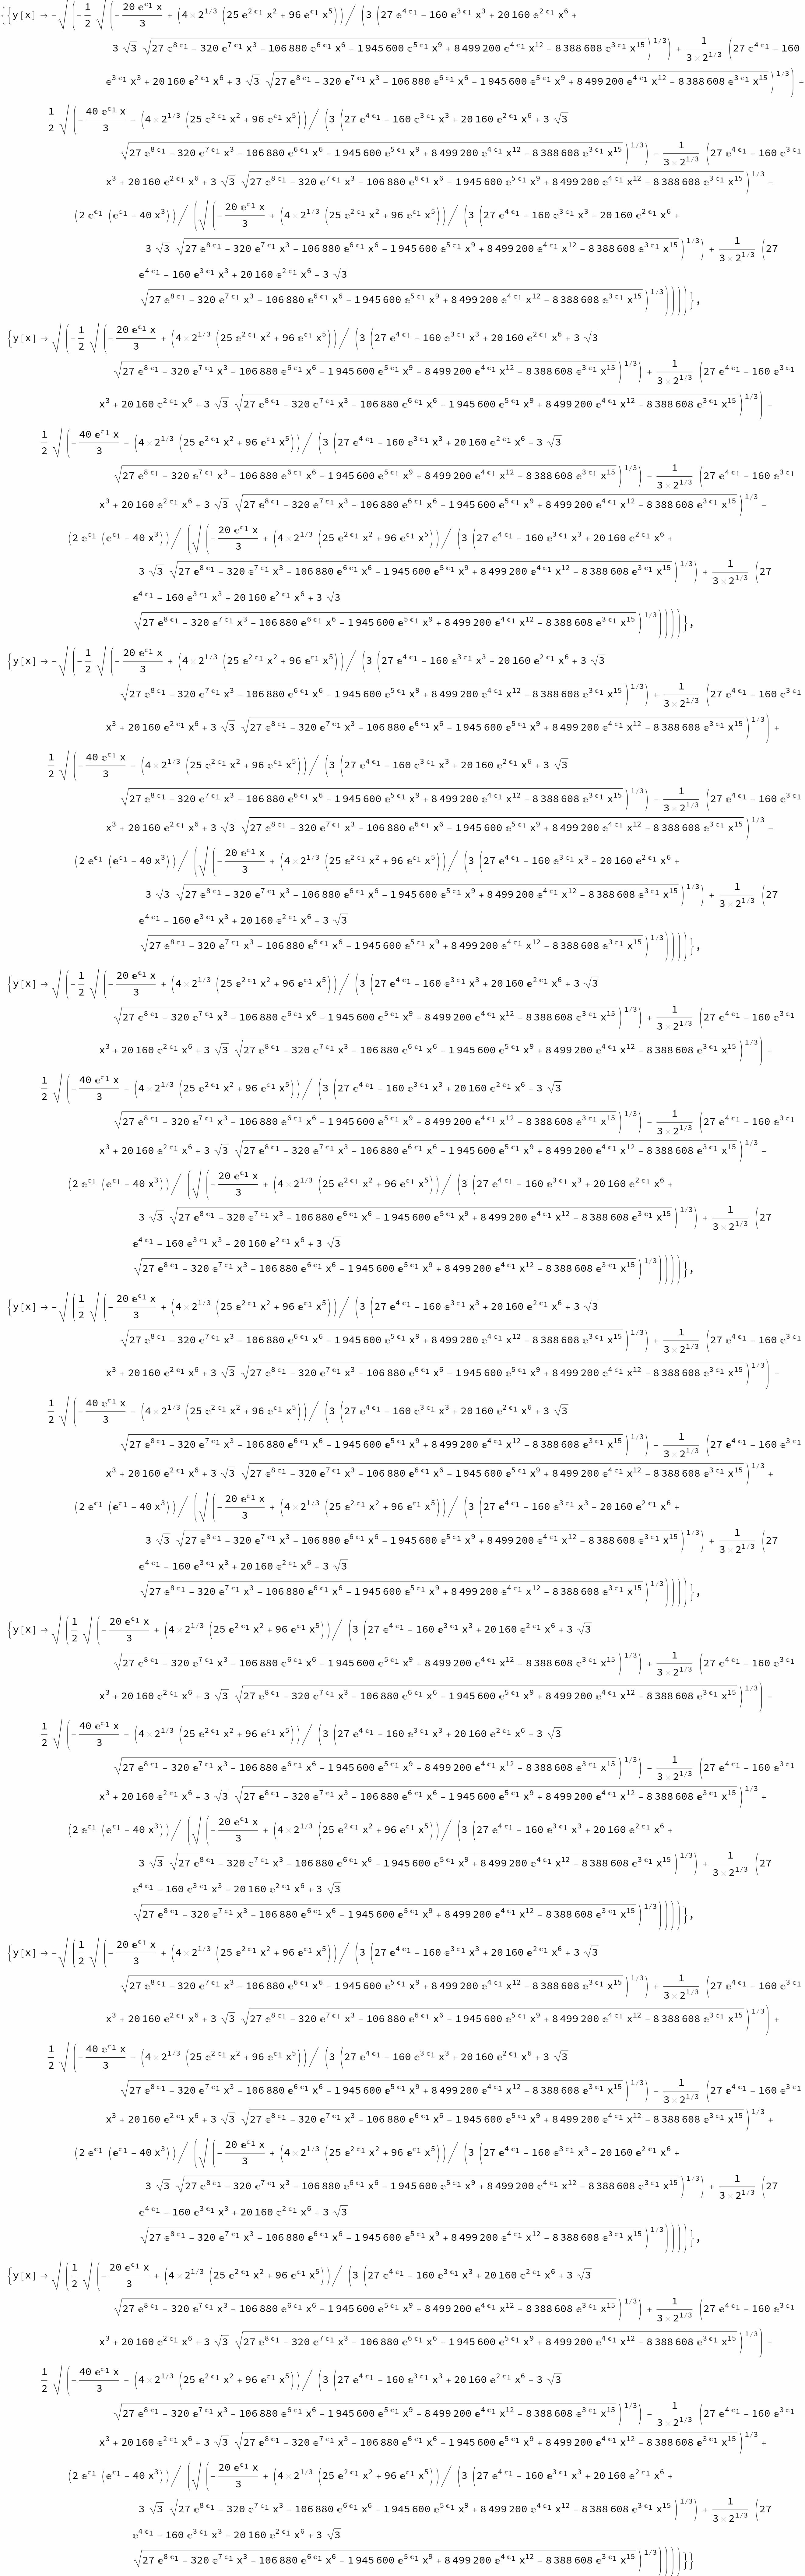

In [41]:
(* --- 4. Аналитическое решение через DSolve --- *)
generalSol = DSolve[ode, y[x], x]
(* DSolve может вернуть решение в неявном виде или через 
   InverseFunction — это нормально для этого класса уравнений *)

In [44]:
(* --- 5. Численное решение с начальным условием --- *)
sol = NDSolve[
   {ode, y[x0] == y0},
   y, {x, 10^-4, x0}
   ];

-Graphics-
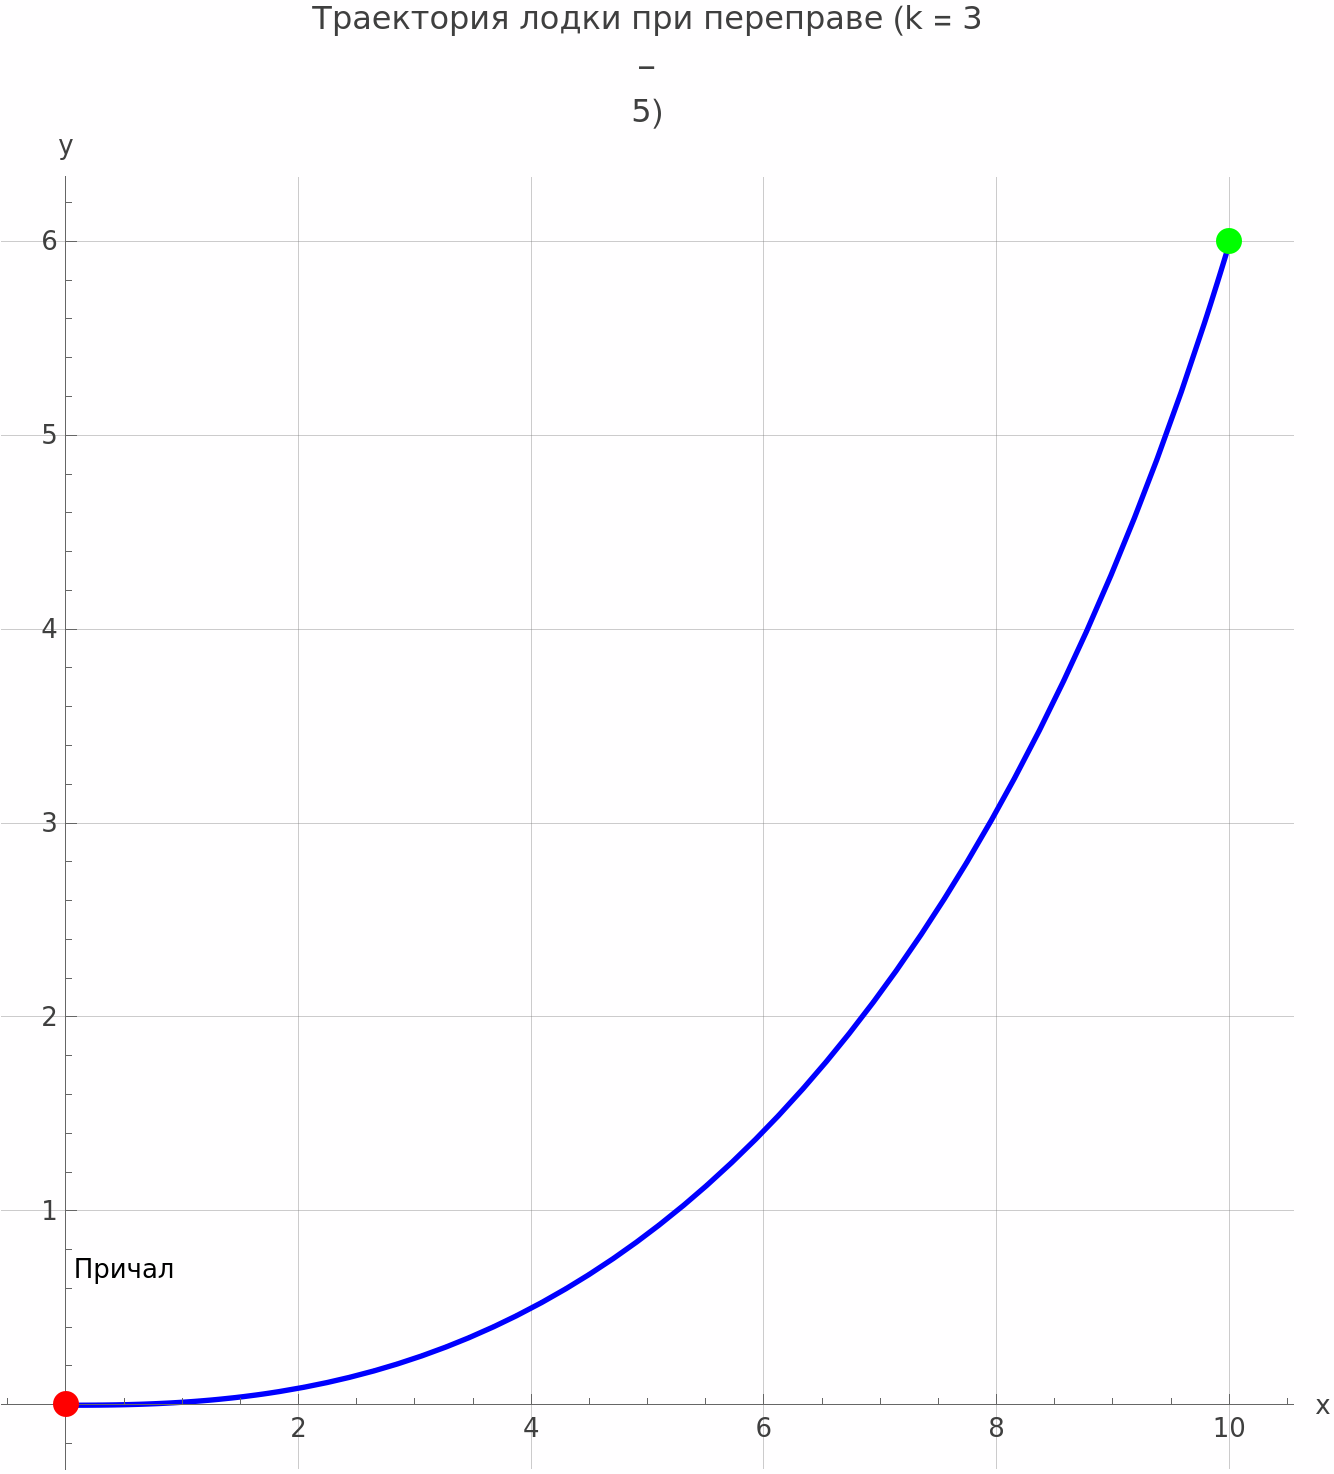

In [46]:
(* --- 6. Визуализация траектории --- *)
trajectoryPlot = ParametricPlot[
   {x, y[x] /. sol[[1]]},
   {x, 10^-4, x0},
   PlotStyle -> {Thick, Blue},
   PlotRange -> All,
   AspectRatio -> 1,
   AxesLabel -> {"x", "y"},
   PlotLabel -> "Траектория лодки при переправе (k = " <> ToString[kVal] <> ")",
   Epilog -> {
     {Red, PointSize[0.02], Point[{0, 0}]},
     {Black, Text["Причал", {0.5, 0.7}]},
     {Green, PointSize[0.02], Point[{x0, y0}]},
     {Black, Text["Старт", {x0 - 1, y0 + 0.7}]}
     },
   GridLines -> Automatic,
   ImageSize -> 500
   ]